In [2]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import sys
sys.executable

'c:\\temp\\python_learning\\ml_projects\\ml_projects_batch_01\\02_telco_customer_churn\\.venv\\Scripts\\python.exe'

In [4]:
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"

PROJECT_ROOT, DATA_PATH

(WindowsPath('c:/temp/python_learning/ml_projects/ml_projects_batch_01/02_telco_customer_churn'),
 WindowsPath('c:/temp/python_learning/ml_projects/ml_projects_batch_01/02_telco_customer_churn/data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv'))

In [5]:
df = pd.read_csv(DATA_PATH)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.shape

(7043, 21)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [8]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [9]:
df.isna().sum().sort_values(ascending=False)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df["InternetService"].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

In [12]:
df["Churn"].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

Предварительно target: churn. Бинарный таргет.
Предварительно ID column: customerID, содержит ID пользователей и не несет смысла для моделей.
Подозрительные колонки по dtype: почти со всеми колонками придется работать - переводить в нужный формат. Например, SeniorCitizen уже в бинарном формате (0,1), MonthlyCharges и TotalCharges в формате str, хотя по факту являются float, многоклассовая классификация точно у MultipleLines, InternetService, PaymentMethod.

In [13]:
df.nunique().sort_values(ascending=False)

customerID          7043
TotalCharges        6531
MonthlyCharges      1585
tenure                73
PaymentMethod          4
StreamingMovies        3
TechSupport            3
OnlineBackup           3
StreamingTV            3
DeviceProtection       3
MultipleLines          3
InternetService        3
OnlineSecurity         3
Contract               3
Partner                2
SeniorCitizen          2
gender                 2
Dependents             2
PhoneService           2
PaperlessBilling       2
Churn                  2
dtype: int64

In [14]:
pd.set_option('display.max_rows', None)
for col in df.columns:
    print(f"\n{col}")
    print(df[col].unique()[:20])


customerID
<StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 '9763-GRSKD', '7469-LKBCI', '8091-TTVAX', '0280-XJGEX', '5129-JLPIS',
 '3655-SNQYZ', '8191-XWSZG', '9959-WOFKT', '4190-MFLUW', '4183-MYFRB']
Length: 20, dtype: str

gender
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

SeniorCitizen
[0 1]

Partner
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Dependents
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

tenure
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30]

PhoneService
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

MultipleLines
<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

InternetService
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

OnlineSecurity
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

OnlineBackup
<StringArray>
['Yes', 'No', 'No internet service']
Length:

In [15]:
string_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()

for col in string_cols:
    n_blank = (df[col].str.strip() == "").sum()
    if n_blank > 0:
        print(col, n_blank)

TotalCharges 11


In [16]:
df.loc[df["TotalCharges"].str.strip() == "", ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [17]:
total_charges_numeric = pd.to_numeric(df["TotalCharges"], errors="coerce")

total_charges_numeric.isna().sum()

np.int64(11)

In [18]:
df.loc[total_charges_numeric.isna(), ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


TotalCharges should be treated as numeric feature.
It has 11 hidden missing values caused by blank strings.
These rows correspond to customers with tenure = 0.

In [19]:
target_col = "Churn"

id_cols = ["customerID"]

numeric_cols_initial = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
]

categorical_cols_initial = [
    col for col in df.columns
    if col not in numeric_cols_initial + id_cols + [target_col]
]

target_col, id_cols, numeric_cols_initial, categorical_cols_initial

('Churn',
 ['customerID'],
 ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'],
 ['gender',
  'Partner',
  'Dependents',
  'PhoneService',
  'MultipleLines',
  'InternetService',
  'OnlineSecurity',
  'OnlineBackup',
  'DeviceProtection',
  'TechSupport',
  'StreamingTV',
  'StreamingMovies',
  'Contract',
  'PaperlessBilling',
  'PaymentMethod'])

In [20]:
len(numeric_cols_initial), len(categorical_cols_initial)

(4, 15)

In [21]:
for col in categorical_cols_initial:
    print(f"\n{col}: {df[col].nunique()} unique values")
    print(df[col].value_counts(dropna=False))


gender: 2 unique values
gender
Male      3555
Female    3488
Name: count, dtype: int64

Partner: 2 unique values
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents: 2 unique values
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

PhoneService: 2 unique values
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

MultipleLines: 3 unique values
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

InternetService: 3 unique values
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

OnlineSecurity: 3 unique values
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

OnlineBackup: 3 unique values
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

DeviceProtection: 3 unique values
DeviceProtecti

In [22]:
audit_summary = {
    "n_rows": df.shape[0],
    "n_columns": df.shape[1],
    "target": target_col,
    "id_columns": id_cols,
    "numeric_features_initial": numeric_cols_initial,
    "categorical_features_initial": categorical_cols_initial,
    "hidden_missing_total_charges": int((df["TotalCharges"].str.strip() == "").sum()),
    "duplicates": int(df.duplicated().sum()),
}

audit_summary

{'n_rows': 7043,
 'n_columns': 21,
 'target': 'Churn',
 'id_columns': ['customerID'],
 'numeric_features_initial': ['SeniorCitizen',
  'tenure',
  'MonthlyCharges',
  'TotalCharges'],
 'categorical_features_initial': ['gender',
  'Partner',
  'Dependents',
  'PhoneService',
  'MultipleLines',
  'InternetService',
  'OnlineSecurity',
  'OnlineBackup',
  'DeviceProtection',
  'TechSupport',
  'StreamingTV',
  'StreamingMovies',
  'Contract',
  'PaperlessBilling',
  'PaymentMethod'],
 'hidden_missing_total_charges': 11,
 'duplicates': 0}

In [23]:
majority_class_accuracy = df["Churn"].value_counts(normalize=True).max()
majority_class_accuracy

np.float64(0.7346301292063041)

In [24]:
positive_rate = (df["Churn"] == "Yes").mean()
positive_rate

np.float64(0.2653698707936959)

In [25]:
target_summary = (
    df["Churn"]
    .value_counts()
    .rename_axis("Churn")
    .reset_index(name="count")
)

target_summary["proportion"] = target_summary["count"] / len(df)

target_summary

,Churn,count,proportion
0,No,5174,0.73463
1,Yes,1869,0.26537


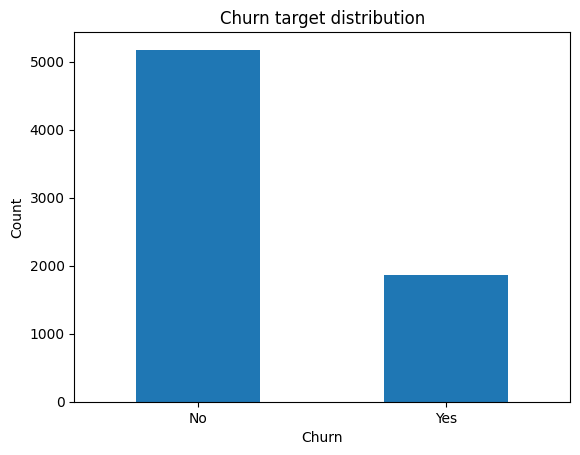

In [26]:
target_summary.plot(
    x="Churn",
    y="count",
    kind="bar",
    legend=False,
    title="Churn target distribution"
)

plt.xlabel("Churn")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

## Target distribution conclusions

- Target column: `Churn`.
- Task type: binary classification.
- Positive class: `Yes`.
- The dataset is moderately imbalanced:
  - majority class `No`: about 73.5%;
  - minority class `Yes`: about 26.5%.
- Accuracy alone is not sufficient as the main metric.
- A naive majority-class model would get about 73.5% accuracy while detecting zero churn cases.
- For this project, recall, precision, F1-score, ROC-AUC and confusion matrix will be more informative than accuracy alone.

In [27]:
df_eda = df.copy()

df_eda["TotalCharges"] = pd.to_numeric(df_eda["TotalCharges"], errors="coerce")

In [28]:
df_eda[["tenure", "MonthlyCharges", "TotalCharges"]].info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   tenure          7043 non-null   int64  
 1   MonthlyCharges  7043 non-null   float64
 2   TotalCharges    7032 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 165.2 KB


In [29]:
df_eda["TotalCharges"].isna().sum()

np.int64(11)

In [30]:
numeric_cols_eda = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]

df_eda[numeric_cols_eda].describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.00,0.000,0.0000,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.000,55.0000,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.350,89.8500,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.45,1397.475,3794.7375,8684.80


In [34]:
df_eda.groupby("Churn")[numeric_cols_eda].agg(["mean", "median"])

SeniorCitizen            tenure        MonthlyCharges          \
               mean median       mean median           mean  median   
Churn                                                                 
No         0.128721    0.0  37.569965   38.0      61.265124  64.425   
Yes        0.254682    0.0  17.979133   10.0      74.441332  79.650   

      TotalCharges           
              mean   median  
Churn                        
No     2555.344141  1683.60  
Yes    1531.796094   703.55

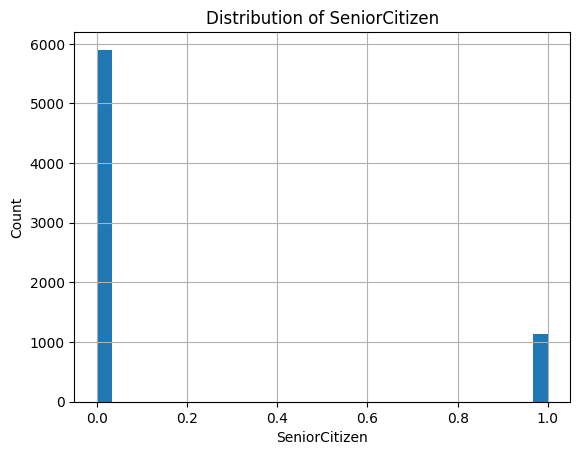

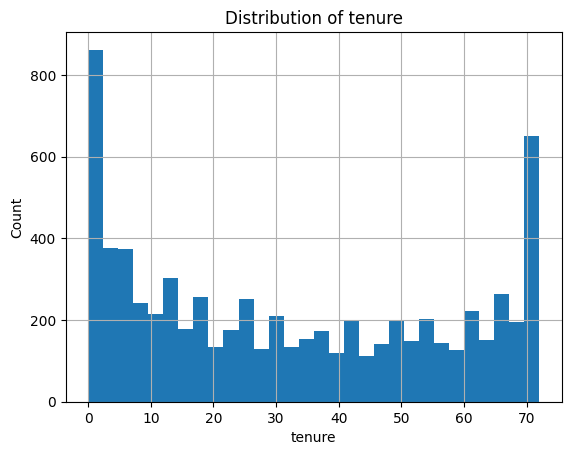

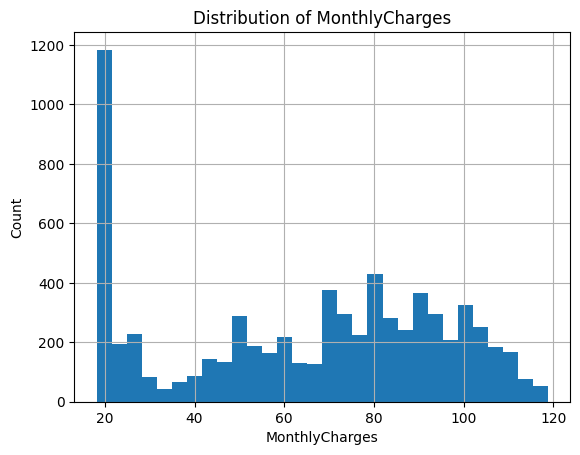

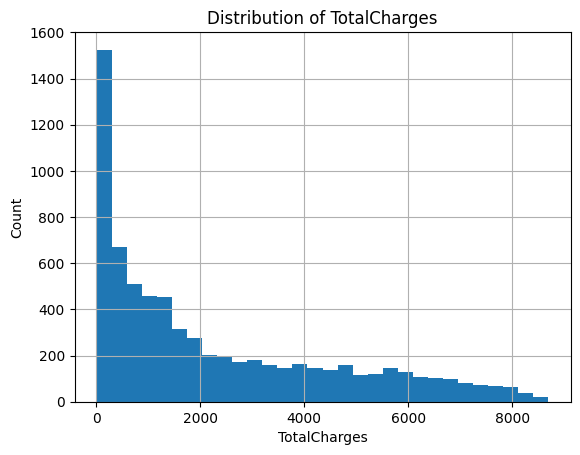

In [32]:
for col in numeric_cols_eda:
    df_eda[col].hist(bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

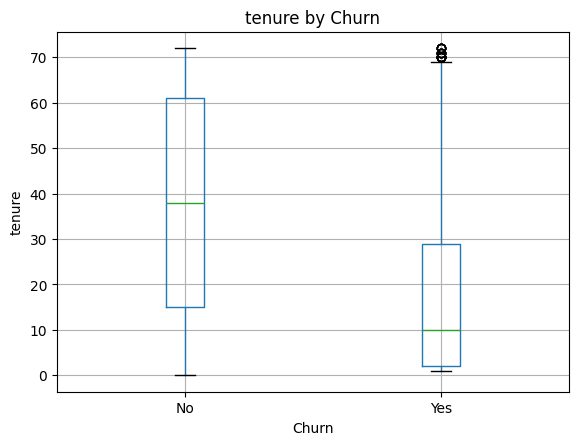

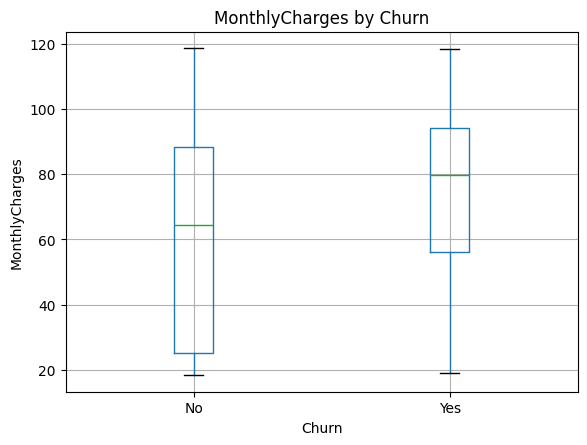

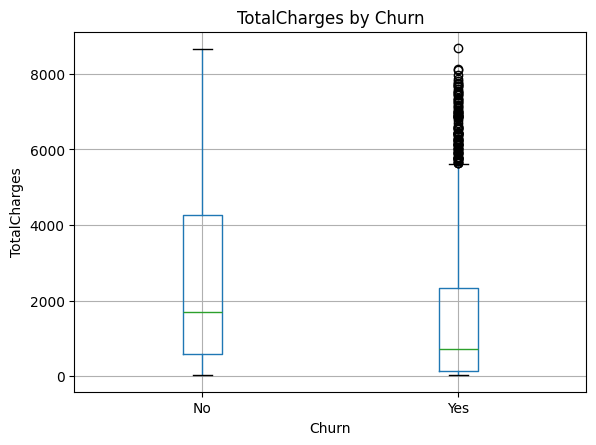

In [33]:
for col in ["tenure", "MonthlyCharges", "TotalCharges"]:
    df_eda.boxplot(column=col, by="Churn")
    plt.title(f"{col} by Churn")
    plt.suptitle("")
    plt.xlabel("Churn")
    plt.ylabel(col)
    plt.show()

In [35]:
senior_churn_rate = (
    df_eda
    .groupby("SeniorCitizen")["Churn"]
    .value_counts(normalize=True)
    .rename("proportion")
    .reset_index()
)

senior_churn_rate

,SeniorCitizen,Churn,proportion
0,0,No,0.763938
1,0,Yes,0.236062
2,1,No,0.583187
3,1,Yes,0.416813


In [36]:
senior_churn_rate_wide = (
    df_eda
    .groupby("SeniorCitizen")["Churn"]
    .apply(lambda x: (x == "Yes").mean())
    .rename("churn_rate")
    .reset_index()
)

senior_churn_rate_wide

,SeniorCitizen,churn_rate
0,0,0.236062
1,1,0.416813


## Numeric feature conclusions

- `tenure` ranges from 0 to 72 months.
- `MonthlyCharges` ranges from 18.25 to 118.75.
- `TotalCharges` was converted to numeric for EDA only.
- `TotalCharges` has 11 missing values after conversion; these correspond to blank strings in the raw data.
- Customers with `Churn = Yes` have much lower tenure on average:
  - median tenure for `No`: 38 months;
  - median tenure for `Yes`: 10 months.
- Customers with `Churn = Yes` have higher monthly charges on average:
  - median MonthlyCharges for `No`: about 64.4;
  - median MonthlyCharges for `Yes`: about 79.7.
- `TotalCharges` is lower for churned customers, but this is strongly affected by lower `tenure`.
- `SeniorCitizen` is a binary indicator, not a continuous numeric feature.
- Initial observation: churn rate appears higher among senior customers, but this should be interpreted as association, not causation.

In [37]:
categorical_cols_eda = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod",
]

categorical_cols_eda

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [38]:
df_eda[categorical_cols_eda].nunique().sort_values(ascending=False)

PaymentMethod       4
InternetService     3
OnlineSecurity      3
DeviceProtection    3
TechSupport         3
OnlineBackup        3
MultipleLines       3
StreamingTV         3
StreamingMovies     3
Contract            3
Dependents          2
PhoneService        2
gender              2
Partner             2
PaperlessBilling    2
dtype: int64

In [39]:
for col in categorical_cols_eda:
    print(f"\n{col}")
    print(df_eda[col].value_counts(dropna=False))


gender
gender
Male      3555
Female    3488
Name: count, dtype: int64

Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

PhoneService
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

MultipleLines
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

InternetService
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

OnlineSecurity
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

OnlineBackup
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

DeviceProtection
DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64

TechSupport
TechSupport
No             

In [40]:
for col in categorical_cols_eda:
    churn_rate_by_category = (
        df_eda
        .groupby(col)["Churn"]
        .apply(lambda x: (x == "Yes").mean())
        .sort_values(ascending=False)
    )
    
    print(f"\n{col}")
    print(churn_rate_by_category)


gender
gender
Female    0.269209
Male      0.261603
Name: Churn, dtype: float64

Partner
Partner
No     0.329580
Yes    0.196649
Name: Churn, dtype: float64

Dependents
Dependents
No     0.312791
Yes    0.154502
Name: Churn, dtype: float64

PhoneService
PhoneService
Yes    0.267096
No     0.249267
Name: Churn, dtype: float64

MultipleLines
MultipleLines
Yes                 0.286099
No                  0.250442
No phone service    0.249267
Name: Churn, dtype: float64

InternetService
InternetService
Fiber optic    0.418928
DSL            0.189591
No             0.074050
Name: Churn, dtype: float64

OnlineSecurity
OnlineSecurity
No                     0.417667
Yes                    0.146112
No internet service    0.074050
Name: Churn, dtype: float64

OnlineBackup
OnlineBackup
No                     0.399288
Yes                    0.215315
No internet service    0.074050
Name: Churn, dtype: float64

DeviceProtection
DeviceProtection
No                     0.391276
Yes                   

In [41]:
important_categorical_cols = [
    "Contract",
    "InternetService",
    "OnlineSecurity",
    "TechSupport",
    "PaymentMethod",
    "PaperlessBilling",
]

for col in important_categorical_cols:
    summary = (
        df_eda
        .groupby(col)
        .agg(
            count=("Churn", "size"),
            churn_rate=("Churn", lambda x: (x == "Yes").mean())
        )
        .sort_values("churn_rate", ascending=False)
    )
    
    print(f"\n{col}")
    display(summary)


Contract


,count,churn_rate
Contract,,
Month-to-month,3875,0.427097
One year,1473,0.112695
Two year,1695,0.028319



InternetService


,count,churn_rate
InternetService,,
Fiber optic,3096,0.418928
DSL,2421,0.189591
No,1526,0.074050



OnlineSecurity


...

,count,churn_rate
TechSupport,,
No,3473,0.416355
Yes,2044,0.151663
No internet service,1526,0.074050



PaymentMethod


,count,churn_rate
PaymentMethod,,
Electronic check,2365,0.452854
Mailed check,1612,0.191067
Bank transfer (automatic),1544,0.167098
Credit card (automatic),1522,0.152431



PaperlessBilling


,count,churn_rate
PaperlessBilling,,
Yes,4171,0.335651
No,2872,0.163301


## Categorical feature conclusions

- Several categorical features show strong differences in churn rate.
- `Contract` appears to be one of the strongest categorical signals:
  - Month-to-month: about 42.7% churn rate;
  - One year: about 11.3%;
  - Two year: about 2.8%.
- Customers with `OnlineSecurity = No` have much higher churn rate than customers with `OnlineSecurity = Yes`.
- Customers with `TechSupport = No` have much higher churn rate than customers with `TechSupport = Yes`.
- `PaymentMethod = Electronic check` has the highest churn rate among payment methods, about 45.3%.
- `InternetService = Fiber optic` has higher churn rate than DSL or no internet service.
- `PaperlessBilling = Yes` has higher churn rate than `PaperlessBilling = No`.
- Categories such as `No internet service` and `No phone service` are meaningful service-status categories and should not be blindly merged with `No`.
- These are univariate associations, not causal conclusions.
- Final preprocessing should handle categorical variables with `OneHotEncoder` inside a `ColumnTransformer`, not with manual ad-hoc encoding.

- Categories such as `No internet service` and `No phone service` are not equivalent to a simple `No`.
  They indicate that the base service is absent, so the related add-on service is not applicable.

In [42]:
numeric_cols_for_corr = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]

corr_matrix = df_eda[numeric_cols_for_corr].corr()

corr_matrix

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.016567,0.220173,0.102411
tenure,0.016567,1.000000,0.247900,0.825880
MonthlyCharges,0.220173,0.247900,1.000000,0.651065
TotalCharges,0.102411,0.825880,0.651065,1.000000


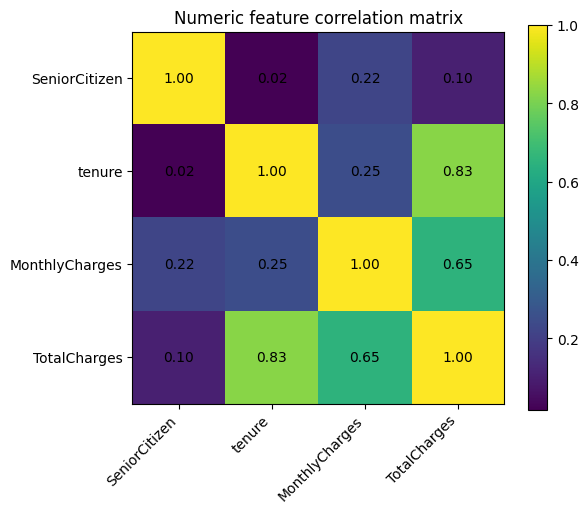

In [43]:
fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(corr_matrix)

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.index)))

ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(corr_matrix.index)

for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center")

plt.title("Numeric feature correlation matrix")
plt.colorbar(im)
plt.show()

In [44]:
df_eda["estimated_total_charges"] = df_eda["tenure"] * df_eda["MonthlyCharges"]

df_eda[["tenure", "MonthlyCharges", "TotalCharges", "estimated_total_charges"]].head()

,tenure,MonthlyCharges,TotalCharges,estimated_total_charges
0,1,29.85,29.85,29.85
1,34,56.95,1889.50,1936.30
2,2,53.85,108.15,107.70
3,45,42.30,1840.75,1903.50
4,2,70.70,151.65,141.40


In [45]:
df_eda[["TotalCharges", "estimated_total_charges"]].corr()

,TotalCharges,estimated_total_charges
TotalCharges,1.00000,0.99956
estimated_total_charges,0.99956,1.00000


In [46]:
df_eda["total_charges_diff"] = df_eda["TotalCharges"] - df_eda["estimated_total_charges"]

df_eda["total_charges_diff"].describe()

count    7032.000000
mean        0.153193
std        67.255326
min      -370.850000
25%       -28.650000
50%         0.000000
75%        28.700000
max       373.250000
Name: total_charges_diff, dtype: float64

## Numeric correlation conclusions

- `TotalCharges` is strongly positively correlated with `tenure`:
  - correlation is about 0.83.
- This is expected because longer-tenured customers usually accumulate higher total charges.
- `TotalCharges` is also positively correlated with `MonthlyCharges`:
  - correlation is about 0.65.
- `TotalCharges` is almost perfectly correlated with `tenure * MonthlyCharges`:
  - correlation is about 0.9996.
- This means `TotalCharges` is very close to a derived accumulated feature.
- However, `TotalCharges` is not exactly equal to `tenure * MonthlyCharges`.
- The difference has median around 0, but some customers have deviations of several hundred units.
- Possible reasons:
  - tariff changes;
  - discounts;
  - partial billing periods;
  - current `MonthlyCharges` may not represent historical average monthly charges.
- This is not an obvious leakage feature, because it describes information that could be known at prediction time.
- But it may be redundant with `tenure` and `MonthlyCharges`.
- At this stage we keep it as a candidate feature and let validation decide later whether it helps.

## Stage 1 EDA summary

### Dataset

- Dataset has 7043 rows and 21 columns.
- Target: `Churn`.
- Task type: binary classification.
- Positive class: `Churn = Yes`.

### Target

- The target is moderately imbalanced:
  - `No`: about 73.5%;
  - `Yes`: about 26.5%.
- Accuracy alone is not enough because a majority-class baseline would already achieve about 73.5% accuracy while detecting no churn cases.

### Numeric features

- Initial numeric features:
  - `SeniorCitizen`
  - `tenure`
  - `MonthlyCharges`
  - `TotalCharges`
- `SeniorCitizen` is a binary indicator encoded as 0/1.
- `TotalCharges` is semantically numeric but loaded as string in the raw CSV.
- `TotalCharges` has 11 hidden missing values represented by blank strings.
- For EDA, `TotalCharges` was temporarily converted to numeric.
- Customers with `Churn = Yes` tend to have lower `tenure`.
- Customers with `Churn = Yes` tend to have higher `MonthlyCharges`.
- `TotalCharges` is strongly related to `tenure` and almost perfectly correlated with `tenure * MonthlyCharges`.
- `TotalCharges` may be redundant, but it should not be automatically removed without validation.

### Categorical features

- Several categorical features show strong univariate association with churn:
  - `Contract`
  - `OnlineSecurity`
  - `TechSupport`
  - `PaymentMethod`
  - `InternetService`
  - `PaperlessBilling`
- `Contract = Month-to-month` has much higher churn rate than one-year or two-year contracts.
- `OnlineSecurity = No` and `TechSupport = No` are associated with higher churn rate.
- `PaymentMethod = Electronic check` has the highest churn rate among payment methods.
- Service-status categories such as `No internet service` and `No phone service` should not be blindly merged with ordinary `No`.

### Leakage and preprocessing notes

- `customerID` is an identifier and must be excluded from feature matrix.
- No obvious direct leakage feature was found during EDA.
- `TotalCharges` conversion and imputation must be handled carefully in the modeling pipeline.
- Categorical features should be handled with `OneHotEncoder` inside `ColumnTransformer`.
- We should not use `pd.get_dummies()` on the full dataset as final training logic.
- Anything that learns from data must be fitted only on train data or inside cross-validation.
- Test set must be kept untouched until final evaluation.